In [1]:
import os, math, random, sys
from datetime import datetime
from collections import deque, namedtuple

import gym
from gym import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from pythermalcomfort.models import pmv_ppd

from models.dqn import DQNAgent
from models.ppo import PPOAgent
from models.sac import SACAgent
from models.td3 import TD3Agent

from models.model_saver_with_loader import save_agent, load_agent, make_run_tag, adv_tag, irr_tag

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using device: cuda


## Hyperparameters
Edit here before running.

In [2]:
# ── Training settings ───────────────────────────────────────────────────────
NUM_EPISODES = 365   # training episodes per agent
TRIAL        = 0     # increment when you re-run experiments (keeps filenames unique)

# Use the model_saver naming convention:
#   <agent>_<env_tag>_trial<N>_run<R>_<YYYYMMDD_HHMMSS>.pth
# For a clean (no adversary) baseline we use the tag 'clean'.
ENV_TAG = 'clean'

print(f'Example tag: {make_run_tag("ppo", ENV_TAG, trial=TRIAL, run=0)}')

Example tag: ppo_clean_trial0_run0_20260429_140512


## Building HVAC Gymnasium Environment without visualised simulation (rendering)
**IMPORTANT NOTE**:  
RL agents/baselines are trained in an adversarial/irrational input-free offline setting, then deployed in a online setting with adversarial/irrational input

In [ ]:
class BuildingEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, alpha=1, beta=1, EER=11):
        super(BuildingEnv, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.EER = EER
        self.room_width, self.room_height = 800, 600

        self.action_space = spaces.Discrete(9)  # actions are temperature setpoints from 22°C to 30°C
        low = np.array([-10.0, 0.0, -3.0])  # [Outdoor Temp, Occupancy, Aggregated PMV]
        high = np.array([50.0, 1.0, 3.0])
        self.observation_space = spaces.Box(low, high)

        self.time_step = 0
        self.max_steps = 48  # each step is 30 minutes, 48 steps in a day

        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()

        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0

        self.history = {
            'indoor_temp': [], 'outdoor_temp': [], 'hvac_power': [],
            'user_feedback': [], 'occupancy': [], 'time': []
        }

    def generate_outdoor_temperature(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        temp = 28 - 6 * np.cos((time_of_day - 14) * np.pi / 12)  # peaks at 2 PM
        return temp + np.random.normal(0, 1.0)

    def generate_occupancy_level(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        if 9 <= time_of_day < 12 or 13 <= time_of_day < 17:  # normal work hours
            occupancy = np.random.uniform(0.5, 0.8)
        elif 12 <= time_of_day < 13:  # lunch hour (peak)
            occupancy = np.random.uniform(0.8, 1.0)
        elif 8 <= time_of_day < 9 or 17 <= time_of_day < 18:  # transition hours
            occupancy = np.random.uniform(0.2, 0.5)
        else:  # off hours
            occupancy = np.random.uniform(0.0, 0.1)
        return occupancy

    def generate_num_users(self):
        max_users = 1000
        return int(self.occupancy_level * max_users)

    def generate_users(self):
        users = []
        for _ in range(self.num_users):
            user = {
                'x': random.randint(50, self.room_width - 50),
                'y': random.randint(50, self.room_height - 50),
                'met': np.random.uniform(1.0, 1.5),
                'clo': np.random.uniform(0.5, 1.0)
            }
            users.append(user)
        return users

    def generate_user_feedback(self):
        if self.num_users == 0:
            return 0  
        pmv_values = []
        for user in self.users:
            met = user['met']
            clo = user['clo']
            pmv = self.calculate_pmv(met, clo)
            pmv_values.append(pmv)
        aggregated_pmv = np.mean(pmv_values)
        return aggregated_pmv

    def calculate_pmv(self, met, clo):
        tdb = self.indoor_temp
        tr = tdb  # mean radiant temperature
        rh = 50.0  # relative humidity
        v = 0.1  # air velocity

        pmv_result = pmv_ppd(tdb=tdb, tr=tr, vr=v, rh=rh, met=met, clo=clo, standard='ASHRAE')
        return pmv_result['pmv']

    def step(self, action, constant_setpoint=None):
        if constant_setpoint is not None:
            self.setpoint_temp = constant_setpoint
        else:
            self.setpoint_temp = 22 + action

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER  # simplified power model

        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        solar_gain = np.sin((time_of_day - 6) * np.pi / 12) * 0.05
        solar_gain = max(0.0, solar_gain)

        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5

        self.indoor_temp += outdoor_influence + hvac_influence + solar_gain

        self.time_step += 1
        done = self.time_step >= self.max_steps
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.user_feedback = self.generate_user_feedback()

        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 100.0)  # only energy consumption penalty
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 100.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        
        # NORMALIZING REWARD
        reward = reward / 10.0

        self.history['indoor_temp'].append(self.indoor_temp)
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state, reward, done, {}

    def reset(self):
        self.time_step = 0
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0

        for key in self.history.keys():
            self.history[key] = []

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state

    def render(self):
        pass

# RL baselines training

## Generic training loop

Works for any agent that exposes `.select_action()`, `.memorize()`,
`.optimize_model()`, and `.save_model()`.

In [4]:
def train_agent(agent, env, num_episodes, agent_label='Agent', print_every=10):
    """
    Standard episodic training loop for PPO / SAC / TD3.

    Parameters
    ----------
    agent        : agent instance with select_action / memorize / optimize_model
    env          : BuildingEnv instance
    num_episodes : int
    agent_label  : str  – used for progress printing
    print_every  : int  – how often to print average reward

    Returns
    -------
    rewards : list[float]  – total reward per episode
    """
    rewards = []
    for episode in range(1, num_episodes + 1):
        state   = env.reset()
        state_t = torch.tensor([state], dtype=torch.float32, device=device)
        ep_reward = 0.0

        for _ in range(env.max_steps):
            action  = agent.select_action(state_t)           # (1, 1) long tensor
            ns, r, done, _ = env.step(action.item())

            r_t  = torch.tensor([r],  dtype=torch.float32, device=device)
            ns_t = (torch.tensor([ns], dtype=torch.float32, device=device)
                    if not done else None)

            agent.memorize(state_t, action, ns_t, r_t)
            agent.optimize_model()

            state_t    = ns_t
            ep_reward += r
            if done:
                break

        rewards.append(ep_reward)
        if episode % print_every == 0:
            avg = np.mean(rewards[-print_every:])
            print(f'[{agent_label}] Episode {episode:>4}/{num_episodes}  '
                  f'Avg reward (last {print_every}): {avg:.4f}')

    return rewards


def plot_rewards(rewards_dict, title='Training rewards'):
    plt.figure(figsize=(12, 5))
    for label, rewards in rewards_dict.items():
        plt.plot(rewards, label=label, alpha=0.85)
    plt.xlabel('Episode')
    plt.ylabel('Total reward')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

print('Training loop defined.')

Training loop defined.


---

## 1. PPO training

In [ ]:
env_ppo = BuildingEnv()

ppo_agent = PPOAgent(
    n_observations = env_ppo.observation_space.shape[0],   # 3
    n_actions      = env_ppo.action_space.n,                # 9
    device         = device,
    lr             = 3e-4,
    gamma          = 0.99,
    lam            = 0.95,
    clip_eps       = 0.2,
    n_epochs       = 4,
    batch_size     = 64,
    ent_coef       = 0.01,
    vf_coef        = 0.5,
    update_every   = 48,   # update once per episode (1 day = 48 steps)
)

print('Training PPO ...')
ppo_rewards = train_agent(ppo_agent, env_ppo, NUM_EPISODES, agent_label='PPO')

PPO_TAG  = make_run_tag('ppo', ENV_TAG, trial=TRIAL, run=0)
PPO_PATH = save_agent(ppo_agent, PPO_TAG)

plot_rewards({'PPO': ppo_rewards}, title='PPO – Training Rewards (clean env)')

/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Training PPO ...


/tmp/ipykernel_3376177/454067804.py:20: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/task_177317399617940/croot/libtorch_1773174040398/work/torch/csrc/utils/tensor_new.cpp:253.)
  state_t = torch.tensor([state], dtype=torch.float32, device=device)


---
## 2. SAC Training

/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Training SAC ...
[SAC] Episode   10/365  Avg reward (last 10): -0.9797
[SAC] Episode   20/365  Avg reward (last 10): -0.9431
[SAC] Episode   30/365  Avg reward (last 10): -0.9039
[SAC] Episode   40/365  Avg reward (last 10): -0.8805
[SAC] Episode   50/365  Avg reward (last 10): -0.7911
[SAC] Episode   60/365  Avg reward (last 10): -0.8948
[SAC] Episode   70/365  Avg reward (last 10): -0.7894
[SAC] Episode   80/365  Avg reward (last 10): -0.8095
[SAC] Episode   90/365  Avg reward (last 10): -0.7599
[SAC] Episode  100/365  Avg reward (last 10): -0.6739
[SAC] Episode  110/365  Avg reward (last 10): -0.7760
[SAC] Episode  120/365  Avg reward (last 10): -0.7723
[SAC] Episode  130/365  Avg reward (last 10): -0.7323
[SAC] Episode  140/365  Avg reward (last 10): -0.7689
[SAC] Episode  150/365  Avg reward (last 10): -0.8132
[SAC] Episode  160/365  Avg reward (last 10): -0.6512
[SAC] Episode  170/365  Avg reward (last 10): -0.5394
[SAC] Episode  180/365  Avg reward (last 10): -0.4841
[SAC] Episo

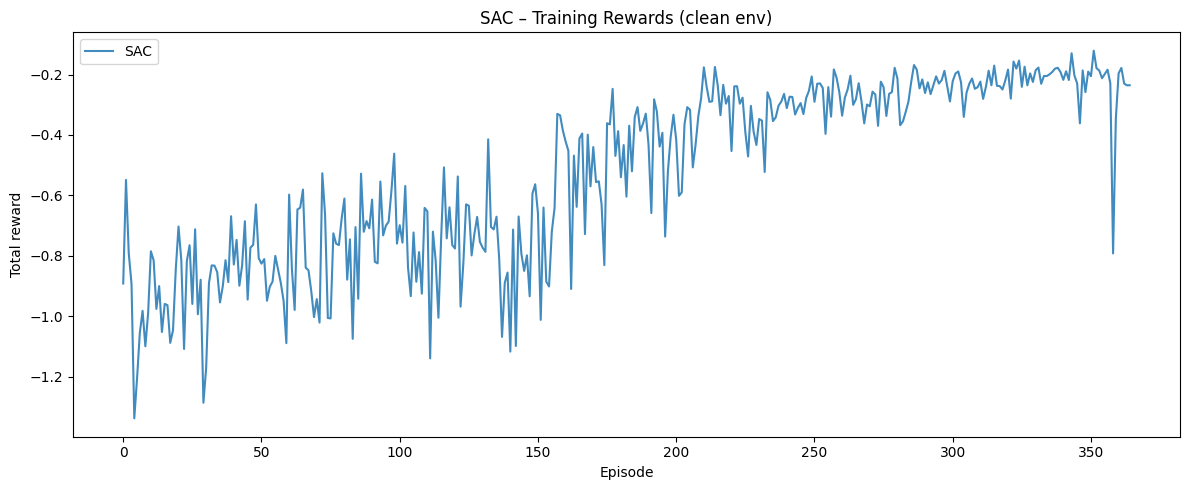

In [ ]:
env_sac = BuildingEnv()

sac_agent = SACAgent(
    n_observations = env_sac.observation_space.shape[0],
    n_actions      = env_sac.action_space.n,
    device         = device,
    lr             = 3e-4,
    gamma          = 0.99,
    tau            = 0.005,
    alpha          = 0.2,
    auto_alpha     = True,
    memory_size    = 10_000,
    batch_size     = 64,
)

print('Training SAC ...')
sac_rewards = train_agent(sac_agent, env_sac, NUM_EPISODES, agent_label='SAC')

SAC_TAG  = make_run_tag('sac', ENV_TAG, trial=TRIAL, run=0)
SAC_PATH = save_agent(sac_agent, SAC_TAG)

plot_rewards({'SAC': sac_rewards}, title='SAC – Training Rewards (clean env)')

---
## 3 · TD3 Training

Training TD3 ...


/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


[TD3] Episode   10/365  Avg reward (last 10): -0.7931
[TD3] Episode   20/365  Avg reward (last 10): -0.6213
[TD3] Episode   30/365  Avg reward (last 10): -0.6862
[TD3] Episode   40/365  Avg reward (last 10): -0.4417
[TD3] Episode   50/365  Avg reward (last 10): -0.4610
[TD3] Episode   60/365  Avg reward (last 10): -0.3501
[TD3] Episode   70/365  Avg reward (last 10): -0.3538
[TD3] Episode   80/365  Avg reward (last 10): -0.3281
[TD3] Episode   90/365  Avg reward (last 10): -0.3108
[TD3] Episode  100/365  Avg reward (last 10): -0.3107
[TD3] Episode  110/365  Avg reward (last 10): -0.2410
[TD3] Episode  120/365  Avg reward (last 10): -0.2477
[TD3] Episode  130/365  Avg reward (last 10): -0.2170
[TD3] Episode  140/365  Avg reward (last 10): -0.2934
[TD3] Episode  150/365  Avg reward (last 10): -0.1930
[TD3] Episode  160/365  Avg reward (last 10): -0.2565
[TD3] Episode  170/365  Avg reward (last 10): -0.2441
[TD3] Episode  180/365  Avg reward (last 10): -0.2956
[TD3] Episode  190/365  Avg 

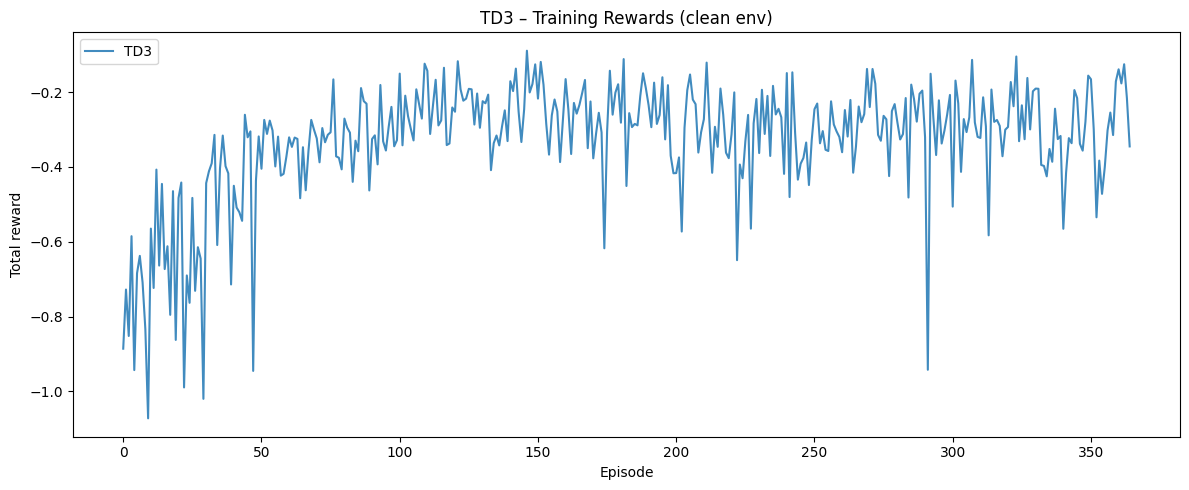

In [ ]:
env_td3 = BuildingEnv()

td3_agent = TD3Agent(
    n_observations = env_td3.observation_space.shape[0],
    n_actions      = env_td3.action_space.n,
    device         = device,
    lr             = 1e-3,
    gamma          = 0.99,
    tau            = 0.005,
    policy_delay   = 2,
    eps_start      = 0.9,
    eps_end        = 0.05,
    eps_decay      = 2000,
    memory_size    = 10_000,
    batch_size     = 64,
)

print('Training TD3 ...')
td3_rewards = train_agent(td3_agent, env_td3, NUM_EPISODES, agent_label='TD3')

TD3_TAG  = make_run_tag('td3', ENV_TAG, trial=TRIAL, run=0)
TD3_PATH = save_agent(td3_agent, TD3_TAG)

plot_rewards({'TD3': td3_rewards}, title='TD3 – Training Rewards (clean env)')

---
## 4 · DQN Training

Same hyperparameters as `RARL_training_main.ipynb` for a fair comparison.

/home/jetwei/miniconda3/envs/hvac/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Training DQN ...
[DQN] Episode   10/365  Avg reward (last 10): -1.5342
[DQN] Episode   20/365  Avg reward (last 10): -1.5181
[DQN] Episode   30/365  Avg reward (last 10): -1.5031
[DQN] Episode   40/365  Avg reward (last 10): -1.5018
[DQN] Episode   50/365  Avg reward (last 10): -1.4119
[DQN] Episode   60/365  Avg reward (last 10): -1.4241
[DQN] Episode   70/365  Avg reward (last 10): -1.2946
[DQN] Episode   80/365  Avg reward (last 10): -1.2961
[DQN] Episode   90/365  Avg reward (last 10): -1.2302
[DQN] Episode  100/365  Avg reward (last 10): -1.2088
[DQN] Episode  110/365  Avg reward (last 10): -1.0640
[DQN] Episode  120/365  Avg reward (last 10): -1.0795
[DQN] Episode  130/365  Avg reward (last 10): -1.1294
[DQN] Episode  140/365  Avg reward (last 10): -1.0846
[DQN] Episode  150/365  Avg reward (last 10): -1.0375
[DQN] Episode  160/365  Avg reward (last 10): -0.9654
[DQN] Episode  170/365  Avg reward (last 10): -0.9857
[DQN] Episode  180/365  Avg reward (last 10): -0.9802
[DQN] Episo

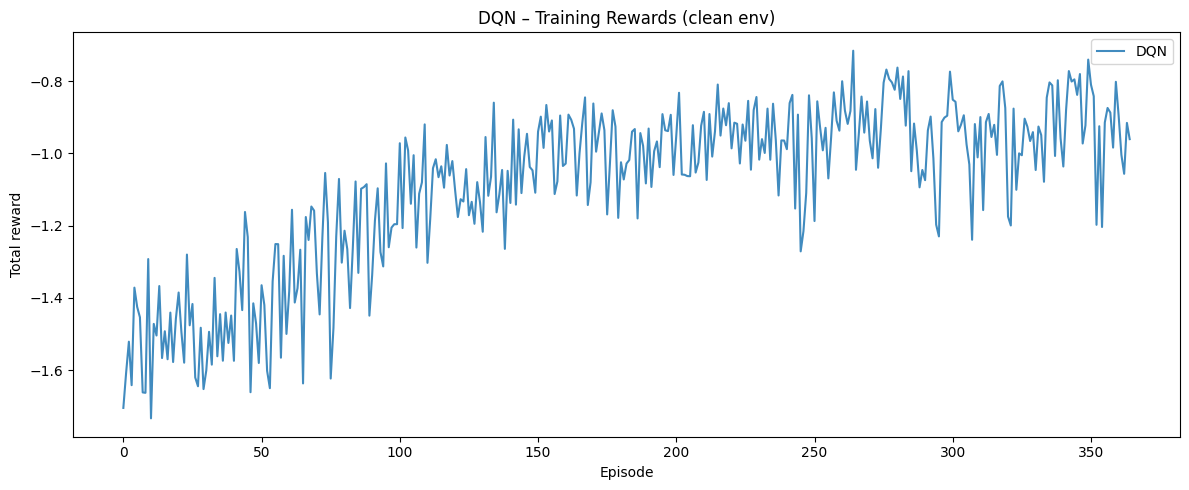

In [ ]:
env_dqn = BuildingEnv()

dqn_agent = DQNAgent(
    n_observations = env_dqn.observation_space.shape[0],   # 3
    n_actions      = env_dqn.action_space.n,                # 9
    device         = device,
    memory_size    = 10_000,
    batch_size     = 64,
    gamma          = 0.99,
    eps_start      = 0.9,
    eps_end        = 0.05,
    eps_decay      = 2000,
    tau            = 0.005,
    lr             = 1e-3,
)

# DQNAgent.select_action() takes an optional train= flag; wrap so the
# generic loop (which calls select_action(state) with no extra args) works.
_orig_select = dqn_agent.select_action
dqn_agent.select_action = lambda state: _orig_select(state, train=True)

print('Training DQN ...')
dqn_rewards = train_agent(dqn_agent, env_dqn, NUM_EPISODES, agent_label='DQN')

DQN_TAG  = make_run_tag('dqn', ENV_TAG, trial=TRIAL, run=0)
DQN_PATH = save_agent(dqn_agent, DQN_TAG)

plot_rewards({'DQN': dqn_rewards}, title='DQN – Training Rewards (clean env)')